# TE vs Gene Density Correlation Analysis

This notebook calculates the correlation between transposable element (TE) density and gene density at the 1 Mb scale for *Danio rerio* (zebrafish).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Load Data

Load both TE density and gene density datasets.

In [2]:
# Load TE density data
te_density = pd.read_csv('Danio_rerio_TE_density_1Mb.tsv', sep='\t')
print(f"TE density data shape: {te_density.shape}")
print(te_density.head())

# Load gene density data
gene_density = pd.read_csv('Danio_rerio_gene_density_1Mb.tsv', sep='\t')
print(f"\nGene density data shape: {gene_density.shape}")
print(gene_density.head())

TE density data shape: (1362, 8)
         chrom  window_index  window_start  window_end  window_size   te_bp  \
0  NC_007112.7             0             1     1000000      1000000  634442   
1  NC_007112.7             1       1000001     2000000      1000000  648724   
2  NC_007112.7             2       2000001     3000000      1000000  618069   
3  NC_007112.7             3       3000001     4000000      1000000  686425   
4  NC_007112.7             4       4000001     5000000      1000000  634211   

   te_fraction  te_count  
0     0.634442      3929  
1     0.648724      3133  
2     0.618069      3266  
3     0.686425      3659  
4     0.634211      3378  

Gene density data shape: (1362, 8)
         chrom  window_index  window_start  window_end  window_size  gene_bp  \
0  NC_007112.7             0             1     1000000      1000000   630698   
1  NC_007112.7             1       1000001     2000000      1000000   327295   
2  NC_007112.7             2       2000001     3000000

## Merge Datasets

Merge TE and gene density data on chromosome and window coordinates.

In [3]:
# Merge on chromosome and window coordinates
merged = pd.merge(
    te_density,
    gene_density[['chrom', 'window_index', 'gene_bp', 'gene_fraction', 'gene_count']],
    on=['chrom', 'window_index'],
    how='inner'
)

print(f"Merged data shape: {merged.shape}")
print(merged.head())

# Summary statistics
print("\nSummary Statistics:")
print(merged[['te_fraction', 'te_count', 'gene_fraction', 'gene_count']].describe())

Merged data shape: (1362, 11)
         chrom  window_index  window_start  window_end  window_size   te_bp  \
0  NC_007112.7             0             1     1000000      1000000  634442   
1  NC_007112.7             1       1000001     2000000      1000000  648724   
2  NC_007112.7             2       2000001     3000000      1000000  618069   
3  NC_007112.7             3       3000001     4000000      1000000  686425   
4  NC_007112.7             4       4000001     5000000      1000000  634211   

   te_fraction  te_count  gene_bp  gene_fraction  gene_count  
0     0.634442      3929   630698       0.630698          48  
1     0.648724      3133   327295       0.327295          13  
2     0.618069      3266   625752       0.625752          13  
3     0.686425      3659   230821       0.230821           1  
4     0.634211      3378    52592       0.052592           1  

Summary Statistics:
       te_fraction     te_count  gene_fraction   gene_count
count  1362.000000  1362.000000    1

## Global Correlation Analysis

Calculate correlation across all chromosomes and windows.

In [4]:
# Pearson correlation (linear relationship)
pearson_frac = stats.pearsonr(merged['te_fraction'], merged['gene_fraction'])
pearson_count = stats.pearsonr(merged['te_count'], merged['gene_count'])

# Spearman correlation (monotonic relationship)
spearman_frac = stats.spearmanr(merged['te_fraction'], merged['gene_fraction'])
spearman_count = stats.spearmanr(merged['te_count'], merged['gene_count'])

print("=" * 60)
print("GLOBAL CORRELATION ANALYSIS")
print("=" * 60)
print("\n--- TE Fraction vs Gene Fraction ---")
print(f"Pearson r = {pearson_frac[0]:.4f}, p-value = {pearson_frac[1]:.2e}")
print(f"Spearman ρ = {spearman_frac[0]:.4f}, p-value = {spearman_frac[1]:.2e}")

print("\n--- TE Count vs Gene Count ---")
print(f"Pearson r = {pearson_count[0]:.4f}, p-value = {pearson_count[1]:.2e}")
print(f"Spearman ρ = {spearman_count[0]:.4f}, p-value = {spearman_count[1]:.2e}")
print("=" * 60)

GLOBAL CORRELATION ANALYSIS

--- TE Fraction vs Gene Fraction ---
Pearson r = -0.1954, p-value = 3.51e-13
Spearman ρ = -0.2426, p-value = 1.08e-19

--- TE Count vs Gene Count ---
Pearson r = 0.0150, p-value = 5.80e-01
Spearman ρ = -0.0638, p-value = 1.86e-02


## Visualization: Scatter Plots

Visualize the relationship between TE and gene density.

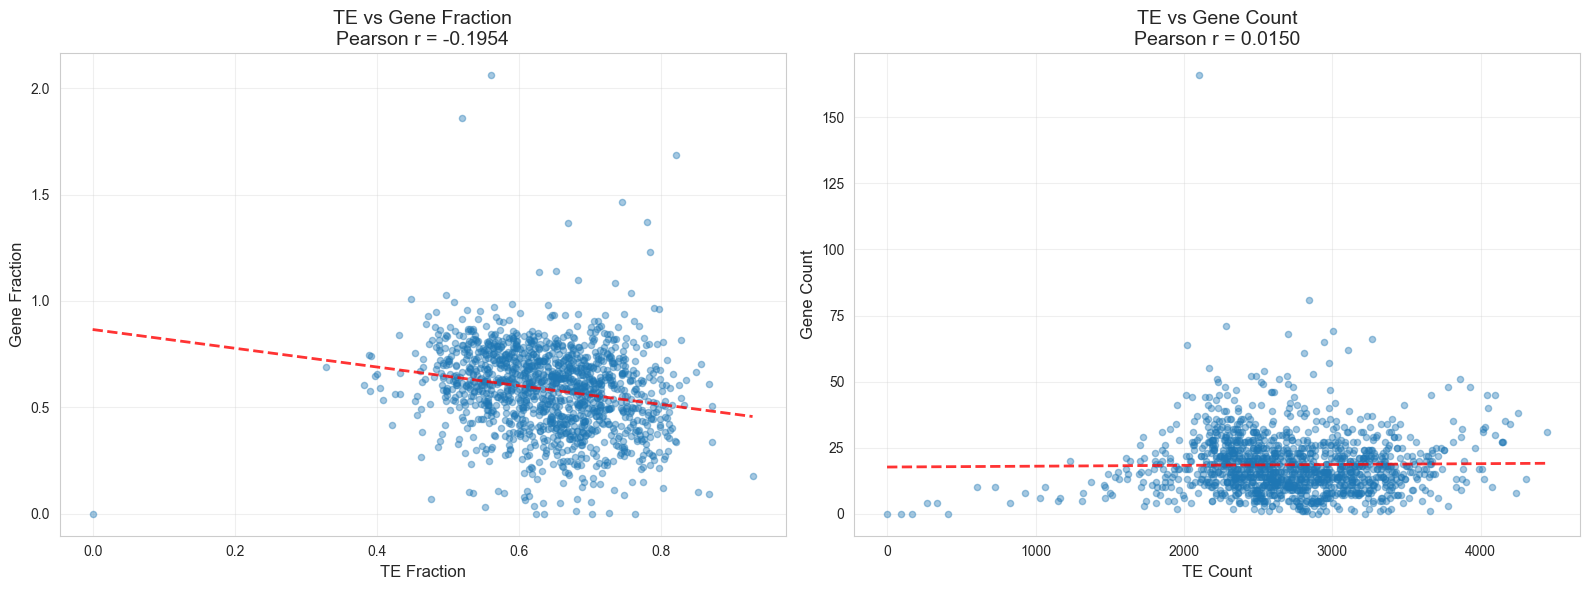

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: TE fraction vs Gene fraction
axes[0].scatter(merged['te_fraction'], merged['gene_fraction'], alpha=0.4, s=20)
axes[0].set_xlabel('TE Fraction', fontsize=12)
axes[0].set_ylabel('Gene Fraction', fontsize=12)
axes[0].set_title(f'TE vs Gene Fraction\nPearson r = {pearson_frac[0]:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(merged['te_fraction'], merged['gene_fraction'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged['te_fraction'].min(), merged['te_fraction'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

# Plot 2: TE count vs Gene count
axes[1].scatter(merged['te_count'], merged['gene_count'], alpha=0.4, s=20)
axes[1].set_xlabel('TE Count', fontsize=12)
axes[1].set_ylabel('Gene Count', fontsize=12)
axes[1].set_title(f'TE vs Gene Count\nPearson r = {pearson_count[0]:.4f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(merged['te_count'], merged['gene_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged['te_count'].min(), merged['te_count'].max(), 100)
axes[1].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('te_gene_correlation_global.png', dpi=300, bbox_inches='tight')
plt.show()

## Per-Chromosome Correlation Analysis

Calculate correlations for each chromosome individually.

In [6]:
# Get major chromosomes (NC_ accessions only, exclude scaffolds)
major_chroms = merged[merged['chrom'].str.startswith('NC_')]['chrom'].unique()
major_chroms = sorted(major_chroms)

# Calculate per-chromosome correlations
chrom_correlations = []

for chrom in major_chroms:
    chrom_data = merged[merged['chrom'] == chrom]
    
    if len(chrom_data) > 2:  # Need at least 3 points for correlation
        pearson_frac = stats.pearsonr(chrom_data['te_fraction'], chrom_data['gene_fraction'])
        spearman_frac = stats.spearmanr(chrom_data['te_fraction'], chrom_data['gene_fraction'])
        
        chrom_correlations.append({
            'chromosome': chrom,
            'n_windows': len(chrom_data),
            'pearson_r': pearson_frac[0],
            'pearson_pval': pearson_frac[1],
            'spearman_rho': spearman_frac[0],
            'spearman_pval': spearman_frac[1]
        })

corr_df = pd.DataFrame(chrom_correlations)
print(corr_df.to_string(index=False))

# Save to file
corr_df.to_csv('te_gene_correlation_per_chromosome.csv', index=False)
print("\nSaved per-chromosome correlations to 'te_gene_correlation_per_chromosome.csv'")

 chromosome  n_windows  pearson_r  pearson_pval  spearman_rho  spearman_pval
NC_007112.7         60  -0.204861      0.116376     -0.221562       0.088882
NC_007113.7         60  -0.289829      0.024689     -0.298861       0.020365
NC_007114.7         63  -0.358148      0.003951     -0.411626       0.000803
NC_007115.7         79  -0.097909      0.390656     -0.217186       0.054525
NC_007116.7         73  -0.242512      0.038712     -0.224577       0.056114
NC_007117.7         61  -0.355328      0.004952     -0.303279       0.017505
NC_007118.7         75  -0.043273      0.712398     -0.063869       0.586174
NC_007119.7         55  -0.381621      0.004042     -0.333117       0.012950
NC_007120.7         57  -0.257646      0.053003     -0.270806       0.041601
NC_007121.7         46  -0.289672      0.050858     -0.199383       0.184029
NC_007122.7         46  -0.328738      0.025704     -0.346161       0.018446
NC_007123.7         50  -0.215949      0.132016     -0.236879       0.097664

In [ ]:
# Find regions with extreme TE or gene density on Chr4
print("=" * 70)
print("CHROMOSOME 4: EXTREME REGIONS")
print("=" * 70)

# High TE, low gene regions
high_te_low_gene = chr4_data[(chr4_data['te_fraction'] > chr4_data['te_fraction'].quantile(0.75)) & 
                              (chr4_data['gene_fraction'] < chr4_data['gene_fraction'].quantile(0.25))]
print(f"\n--- High TE, Low Gene Regions (n={len(high_te_low_gene)}) ---")
if len(high_te_low_gene) > 0:
    print(high_te_low_gene[['window_start', 'window_end', 'te_fraction', 'te_count', 
                             'gene_fraction', 'gene_count']].to_string(index=False))

# Low TE, high gene regions
low_te_high_gene = chr4_data[(chr4_data['te_fraction'] < chr4_data['te_fraction'].quantile(0.25)) & 
                              (chr4_data['gene_fraction'] > chr4_data['gene_fraction'].quantile(0.75))]
print(f"\n--- Low TE, High Gene Regions (n={len(low_te_high_gene)}) ---")
if len(low_te_high_gene) > 0:
    print(low_te_high_gene[['window_start', 'window_end', 'te_fraction', 'te_count', 
                             'gene_fraction', 'gene_count']].to_string(index=False))

# Regions with both high TE and high genes
both_high = chr4_data[(chr4_data['te_fraction'] > chr4_data['te_fraction'].quantile(0.75)) & 
                       (chr4_data['gene_fraction'] > chr4_data['gene_fraction'].quantile(0.75))]
print(f"\n--- Both High TE and Gene Regions (n={len(both_high)}) ---")
if len(both_high) > 0:
    print(both_high[['window_start', 'window_end', 'te_fraction', 'te_count', 
                     'gene_fraction', 'gene_count']].to_string(index=False))

print("\n" + "=" * 70)

# Save Chr4 data to file
chr4_output = chr4_data[['chrom', 'window_index', 'window_start', 'window_end', 
                          'te_bp', 'te_fraction', 'te_count', 
                          'gene_bp', 'gene_fraction', 'gene_count']].copy()
chr4_output.to_csv('chr4_te_gene_correlation.csv', index=False)
print("\nSaved Chr4 correlation data to 'chr4_te_gene_correlation.csv'")

In [ ]:
# Visualize Chr4 TE vs Gene density
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Scatter plot - TE fraction vs Gene fraction
axes[0, 0].scatter(chr4_data['te_fraction'], chr4_data['gene_fraction'], 
                   alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('TE Fraction', fontsize=12)
axes[0, 0].set_ylabel('Gene Fraction', fontsize=12)
axes[0, 0].set_title(f'Chr4: TE vs Gene Fraction\nPearson r = {chr4_pearson_frac[0]:.4f}', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(chr4_data['te_fraction'], chr4_data['gene_fraction'], 1)
p = np.poly1d(z)
x_line = np.linspace(chr4_data['te_fraction'].min(), chr4_data['te_fraction'].max(), 100)
axes[0, 0].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, 
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[0, 0].legend()

# Plot 2: Scatter plot - TE count vs Gene count
axes[0, 1].scatter(chr4_data['te_count'], chr4_data['gene_count'], 
                   alpha=0.6, s=50, c='darkorange', edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('TE Count', fontsize=12)
axes[0, 1].set_ylabel('Gene Count', fontsize=12)
axes[0, 1].set_title(f'Chr4: TE vs Gene Count\nPearson r = {chr4_pearson_count[0]:.4f}', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(chr4_data['te_count'], chr4_data['gene_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(chr4_data['te_count'].min(), chr4_data['te_count'].max(), 100)
axes[0, 1].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2,
                label=f'y = {z[0]:.4f}x + {z[1]:.3f}')
axes[0, 1].legend()

# Plot 3: Distribution of TE fraction along chromosome
chr4_data_sorted = chr4_data.sort_values('window_start')
axes[1, 0].plot(chr4_data_sorted['window_start'] / 1e6, chr4_data_sorted['te_fraction'], 
                'b-', linewidth=2, label='TE Fraction')
axes[1, 0].set_xlabel('Genomic Position (Mb)', fontsize=12)
axes[1, 0].set_ylabel('TE Fraction', fontsize=12, color='b')
axes[1, 0].tick_params(axis='y', labelcolor='b')
axes[1, 0].set_title('Chr4: TE and Gene Density along Chromosome', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)

# Add gene fraction on secondary y-axis
ax2 = axes[1, 0].twinx()
ax2.plot(chr4_data_sorted['window_start'] / 1e6, chr4_data_sorted['gene_fraction'], 
         'r-', linewidth=2, label='Gene Fraction', alpha=0.7)
ax2.set_ylabel('Gene Fraction', fontsize=12, color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends
lines1, labels1 = axes[1, 0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1, 0].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Plot 4: Residuals plot
z = np.polyfit(chr4_data['te_fraction'], chr4_data['gene_fraction'], 1)
predicted = z[0] * chr4_data['te_fraction'] + z[1]
residuals = chr4_data['gene_fraction'] - predicted

axes[1, 1].scatter(chr4_data['te_fraction'], residuals, alpha=0.6, s=50, 
                   c='purple', edgecolors='black', linewidth=0.5)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('TE Fraction', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].set_title('Chr4: Residuals Plot', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chr4_te_gene_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Filter data for chromosome 4
chr4_data = merged[merged['chrom'] == 'NC_007115.7'].copy()

print("=" * 70)
print("CHROMOSOME 4 (NC_007115.7) ANALYSIS")
print("=" * 70)
print(f"\nNumber of 1Mb windows: {len(chr4_data)}")
print(f"Chromosome length: ~{chr4_data['window_end'].max() / 1e6:.1f} Mb")

# Calculate correlations for Chr4
chr4_pearson_frac = stats.pearsonr(chr4_data['te_fraction'], chr4_data['gene_fraction'])
chr4_spearman_frac = stats.spearmanr(chr4_data['te_fraction'], chr4_data['gene_fraction'])
chr4_pearson_count = stats.pearsonr(chr4_data['te_count'], chr4_data['gene_count'])
chr4_spearman_count = stats.spearmanr(chr4_data['te_count'], chr4_data['gene_count'])

print("\n--- TE Fraction vs Gene Fraction ---")
print(f"Pearson r = {chr4_pearson_frac[0]:.4f}, p-value = {chr4_pearson_frac[1]:.4e}")
print(f"Spearman ρ = {chr4_spearman_frac[0]:.4f}, p-value = {chr4_spearman_frac[1]:.4e}")

print("\n--- TE Count vs Gene Count ---")
print(f"Pearson r = {chr4_pearson_count[0]:.4f}, p-value = {chr4_pearson_count[1]:.4e}")
print(f"Spearman ρ = {chr4_spearman_count[0]:.4f}, p-value = {chr4_spearman_count[1]:.4e}")

# Summary statistics for Chr4
print("\n--- TE Density Statistics ---")
print(f"Mean TE fraction: {chr4_data['te_fraction'].mean():.4f} ± {chr4_data['te_fraction'].std():.4f}")
print(f"Range: [{chr4_data['te_fraction'].min():.4f}, {chr4_data['te_fraction'].max():.4f}]")
print(f"Mean TE count: {chr4_data['te_count'].mean():.1f} ± {chr4_data['te_count'].std():.1f}")

print("\n--- Gene Density Statistics ---")
print(f"Mean gene fraction: {chr4_data['gene_fraction'].mean():.4f} ± {chr4_data['gene_fraction'].std():.4f}")
print(f"Range: [{chr4_data['gene_fraction'].min():.4f}, {chr4_data['gene_fraction'].max():.4f}]")
print(f"Mean gene count: {chr4_data['gene_count'].mean():.1f} ± {chr4_data['gene_count'].std():.1f}")

print("\n" + "=" * 70)

## Chromosome 4 (NC_007115.7) Detailed Analysis

Chromosome 4 has unusual TE composition. Let's examine its TE vs gene density correlation in detail.

## Visualization: Per-Chromosome Correlation Heatmap

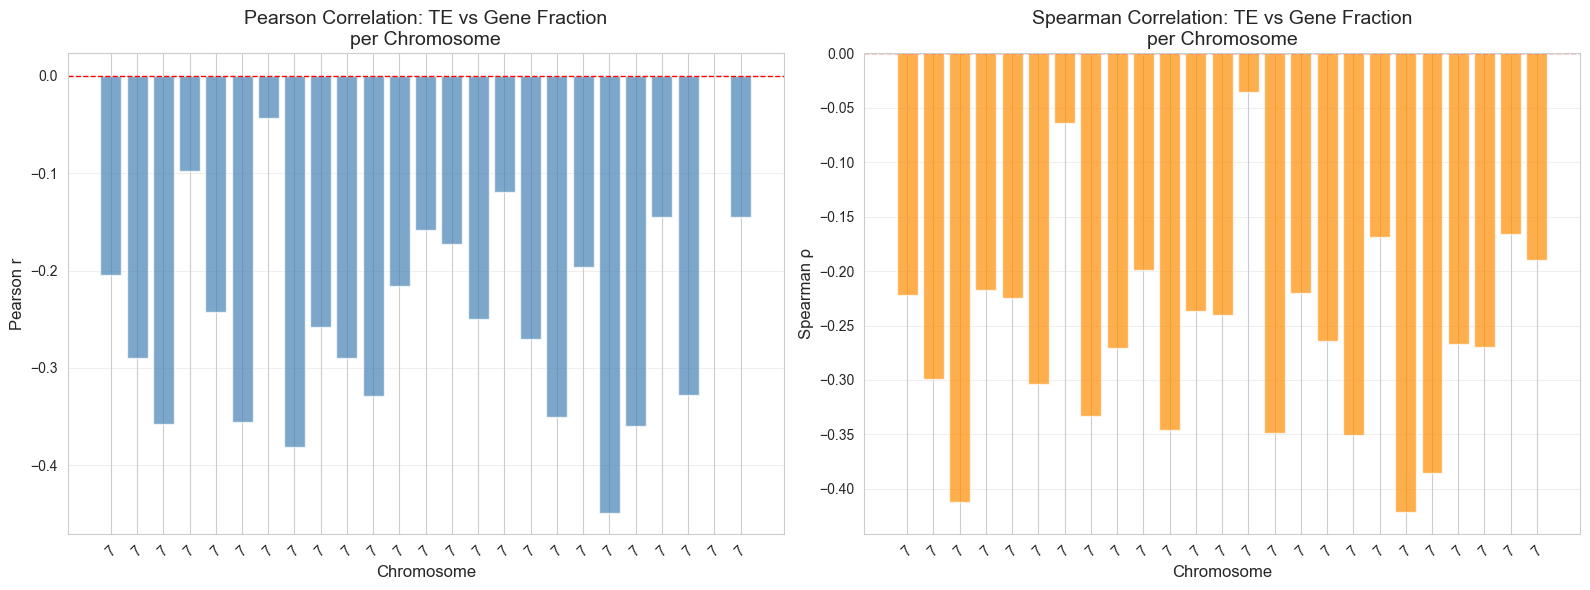

In [7]:
# Extract chromosome numbers for better labeling
corr_df['chr_num'] = corr_df['chromosome'].str.extract(r'NC_\d+\.(\d+)')[0].astype(int)
corr_df = corr_df.sort_values('chr_num')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Pearson correlations
axes[0].bar(range(len(corr_df)), corr_df['pearson_r'], color='steelblue', alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Chromosome', fontsize=12)
axes[0].set_ylabel('Pearson r', fontsize=12)
axes[0].set_title('Pearson Correlation: TE vs Gene Fraction\nper Chromosome', fontsize=14)
axes[0].set_xticks(range(len(corr_df)))
axes[0].set_xticklabels(corr_df['chr_num'], rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot Spearman correlations
axes[1].bar(range(len(corr_df)), corr_df['spearman_rho'], color='darkorange', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Chromosome', fontsize=12)
axes[1].set_ylabel('Spearman ρ', fontsize=12)
axes[1].set_title('Spearman Correlation: TE vs Gene Fraction\nper Chromosome', fontsize=14)
axes[1].set_xticks(range(len(corr_df)))
axes[1].set_xticklabels(corr_df['chr_num'], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('te_gene_correlation_per_chromosome.png', dpi=300, bbox_inches='tight')
plt.show()

## Hexbin Density Plot

Better visualization for dense data points.

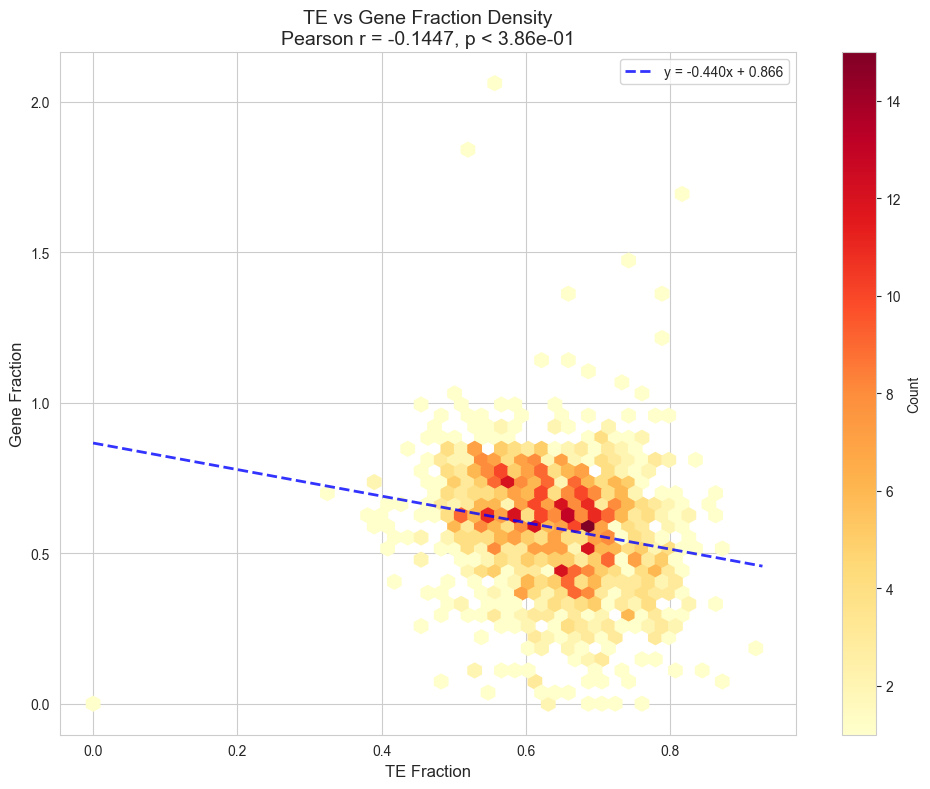

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

hexbin = ax.hexbin(merged['te_fraction'], merged['gene_fraction'], 
                    gridsize=50, cmap='YlOrRd', mincnt=1)
ax.set_xlabel('TE Fraction', fontsize=12)
ax.set_ylabel('Gene Fraction', fontsize=12)
ax.set_title(f'TE vs Gene Fraction Density\nPearson r = {pearson_frac[0]:.4f}, p < {pearson_frac[1]:.2e}', fontsize=14)

# Add regression line
z = np.polyfit(merged['te_fraction'], merged['gene_fraction'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged['te_fraction'].min(), merged['te_fraction'].max(), 100)
ax.plot(x_line, p(x_line), "b--", alpha=0.8, linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

plt.colorbar(hexbin, ax=ax, label='Count')
ax.legend()
plt.tight_layout()
plt.savefig('te_gene_hexbin.png', dpi=300, bbox_inches='tight')
plt.show()

## Statistical Summary

Summary of findings.

In [9]:
print("="*70)
print("TE vs GENE DENSITY CORRELATION SUMMARY")
print("="*70)
print(f"\nTotal 1Mb windows analyzed: {len(merged)}")
print(f"Number of chromosomes: {len(major_chroms)}")

print("\n--- Global Correlation (all chromosomes) ---")
print(f"TE Fraction vs Gene Fraction:")
print(f"  Pearson r = {pearson_frac[0]:.4f} (p = {pearson_frac[1]:.2e})")
print(f"  Spearman ρ = {spearman_frac[0]:.4f} (p = {spearman_frac[1]:.2e})")

print("\n--- Per-Chromosome Statistics ---")
print(f"Mean Pearson r: {corr_df['pearson_r'].mean():.4f} ± {corr_df['pearson_r'].std():.4f}")
print(f"Mean Spearman ρ: {corr_df['spearman_rho'].mean():.4f} ± {corr_df['spearman_rho'].std():.4f}")
print(f"Range Pearson r: [{corr_df['pearson_r'].min():.4f}, {corr_df['pearson_r'].max():.4f}]")
print(f"Range Spearman ρ: [{corr_df['spearman_rho'].min():.4f}, {corr_df['spearman_rho'].max():.4f}]")

# Chromosomes with strongest negative correlation
print("\n--- Strongest Negative Correlations ---")
top_neg = corr_df.nsmallest(3, 'pearson_r')[['chromosome', 'chr_num', 'pearson_r', 'pearson_pval']]
print(top_neg.to_string(index=False))

# Chromosomes with strongest positive correlation (if any)
print("\n--- Strongest Positive Correlations ---")
top_pos = corr_df.nlargest(3, 'pearson_r')[['chromosome', 'chr_num', 'pearson_r', 'pearson_pval']]
print(top_pos.to_string(index=False))

print("\n" + "="*70)

TE vs GENE DENSITY CORRELATION SUMMARY

Total 1Mb windows analyzed: 1362
Number of chromosomes: 26

--- Global Correlation (all chromosomes) ---
TE Fraction vs Gene Fraction:
  Pearson r = -0.1447 (p = 3.86e-01)
  Spearman ρ = -0.1903 (p = 2.53e-01)

--- Per-Chromosome Statistics ---
Mean Pearson r: -0.2403 ± 0.1126
Mean Spearman ρ: -0.2582 ± 0.0954
Range Pearson r: [-0.4487, 0.0009]
Range Spearman ρ: [-0.4207, -0.0352]

--- Strongest Negative Correlations ---
 chromosome  chr_num  pearson_r  pearson_pval
NC_007131.7        7  -0.448717      0.000523
NC_007119.7        7  -0.381621      0.004042
NC_007132.7        7  -0.360103      0.013963

--- Strongest Positive Correlations ---
 chromosome  chr_num  pearson_r  pearson_pval
NC_007135.7        7   0.000913      0.995365
NC_007118.7        7  -0.043273      0.712398
NC_007115.7        7  -0.097909      0.390656

